# A simple example using HESS-I

In [1]:
import astropy.units as u
import jax
import jax.numpy as jnp
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time

from nyx.atmosphere import single_scattering
from nyx.core import Scene
from nyx.core.geometry import Geometry
from nyx.core.observation import Observation
from nyx.emitter import Airglow, Moon, Stars, ZodiacalLight
from nyx.instrument import EffectiveApertureInstrument

E0602 12:42:46.398616  755559 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0602 12:42:46.398729  755560 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0602 12:42:46.398796  755561 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


## Building the model:

We first need to determine the render geometry:

In [2]:
geo = Geometry(
    wvls=jnp.linspace(300, 700, 50) * u.nm,  # wavelength grid
    nside=16,  # HEALPix resolution
    ngrid=2,  # FOV eval grid
    fov=3.5 * u.deg,  # field of view
)

We then load instrument, atmospheric model and source models:

In [3]:
hess_ct1 = EffectiveApertureInstrument.load("../../nyx/data/HESS_CT1.h5", geo)
hess_stereo = {"CT1": hess_ct1, "CT2": hess_ct1, "CT3": hess_ct1, "CT4": hess_ct1}

atmosphere = single_scattering.HGOzoneAbsorption(geo)

sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

## Creating an example observation:
An observations consists out of a single target, an array of observations times and locations:

In [4]:
location_ct1 = EarthLocation.from_geodetic(
    lon=16.50091 * u.deg,
    lat=-23.27153 * u.deg,
    height=1.835 * u.km,
)
location_ct2 = EarthLocation.from_geodetic(
    lon=16.50010 * u.deg,
    lat=-23.27075 * u.deg,
    height=1.835 * u.km,
)
location_ct3 = EarthLocation.from_geodetic(
    lon=16.49925 * u.deg,
    lat=-23.27151 * u.deg,
    height=1.835 * u.km,
)
location_ct4 = EarthLocation.from_geodetic(
    lon=16.50012 * u.deg,
    lat=-23.27232 * u.deg,
    height=1.835 * u.km,
)

times = Time("2021-06-12T02:12:16", scale="utc") + jnp.linspace(0, 30, 120) * 60 * u.s
target = SkyCoord(l=0 * u.deg, b=0 * u.deg, frame="galactic")

obs_ct1 = Observation(location_ct1, times, target, geo)
obs_ct2 = Observation(location_ct2, times, target, geo)
obs_ct3 = Observation(location_ct3, times, target, geo)
obs_ct4 = Observation(location_ct4, times, target, geo)

observations = {"CT1": obs_ct1, "CT2": obs_ct2, "CT3": obs_ct3, "CT4": obs_ct4}

## Querying model for scene
We then build our scene from the models an observations:

In [5]:
scene = Scene.build(hess_stereo, atmosphere, sources, observations)

You can profile the scene before rendering:

In [6]:
from nyx.utils.profiler import profile_render

profile_render(scene)


  Render memory profile (backend=gpu, device=cuda:0)
  Memory before render: 351.3 MB
  Memory after render:  353.3 MB
  Peak memory:          2193.7 MB
  Render overhead:      1.9 MB
  Result shape:         (120, 960)
  Output[CT1]:            (120, 960)  float32  0.44 MB
  Output[CT2]:            (120, 960)  float32  0.44 MB
  Output[CT3]:            (120, 960)  float32  0.44 MB
  Output[CT4]:            (120, 960)  float32  0.44 MB

  Device memory (cuda:0):
    In use:     353.3 MB
    Peak:      2193.7 MB
    Limit:    36407.8 MB
    Free:     36054.5 MB



{'before_mb': 351.30419921875,
 'after_mb': 353.253662109375,
 'peak_mb': 2193.71630859375,
 'render_mb': 1.949462890625,
 'result_shape': (120, 960)}

We can then render the whole scene with one call:

In [7]:
%%time
rates = scene.render()

CPU times: user 2.24 s, sys: 258 ms, total: 2.5 s
Wall time: 2.2 s


By default, this is not jitted. To increase call speed after the first call, you can use jax.jit:

In [8]:
@jax.jit
def f_render():
    return scene.render()

This incurs a higher upfront cost, but future calls are accelerated via jitting:

In [9]:
%%time
rates = jax.block_until_ready(f_render())

CPU times: user 56.8 s, sys: 2.63 s, total: 59.4 s
Wall time: 38.3 s


In [10]:
%%time
rates = jax.block_until_ready(f_render())

CPU times: user 2.04 ms, sys: 99 μs, total: 2.14 ms
Wall time: 74.5 ms


## Plotting the result:
We can plot the generated plot for all four of our telescopes using iactrace:

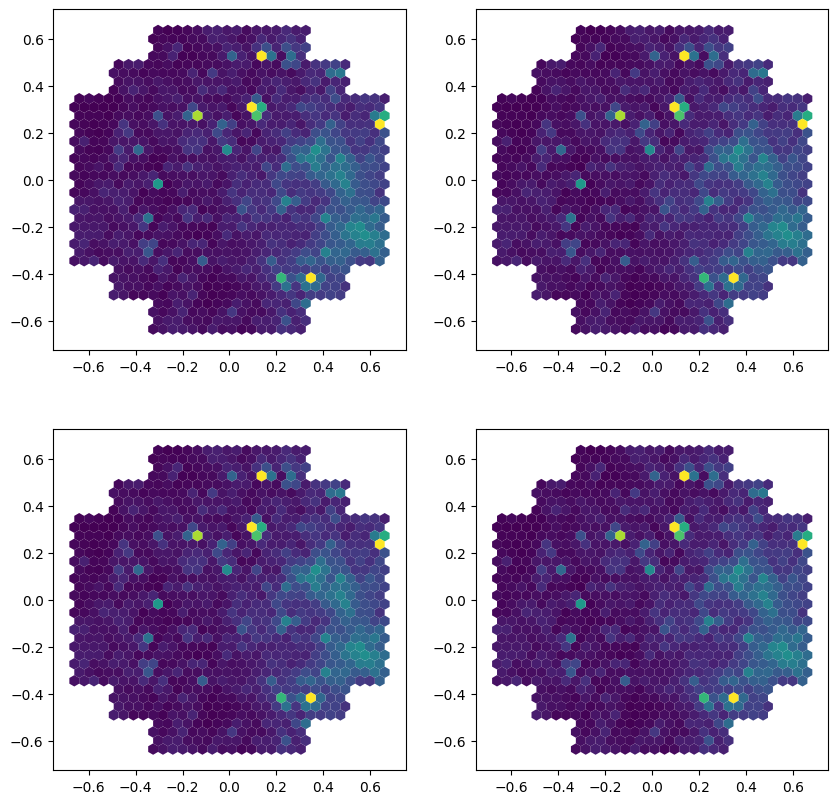

In [11]:
import matplotlib.pyplot as plt
from iactrace import Camera, show_camera

camera = Camera.from_yaml("../../../iactrace/configs/HESS/HESS1U.yaml")

id = 0
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 10))
ax1 = show_camera(rates["CT1"][id : id + 1] / 1e6, camera.sensor_groups[0], ax=ax[0, 0], vmax=500)
ax1 = show_camera(rates["CT2"][id : id + 1] / 1e6, camera.sensor_groups[0], ax=ax[0, 1], vmax=500)
ax1 = show_camera(rates["CT3"][id : id + 1] / 1e6, camera.sensor_groups[0], ax=ax[1, 0], vmax=500)
ax1 = show_camera(rates["CT4"][id : id + 1] / 1e6, camera.sensor_groups[0], ax=ax[1, 1], vmax=500)